# Elliptic LCS from the Cauchy-Green tensor

Elliptic Lagrangian Coherent Structures (LCS) are **material vortex boundaries** — closed
curves that resist filamentation over a finite time window $[t_0, t_1]$.

The algorithm (Haller et al., *J. Fluid Mech.* 795, 2016; implemented in
[CoherentStructures.jl](https://github.com/CoherentStructures/CoherentStructures.jl)) works
in three steps:

1. **Singularity detection** — find cells where the smallest CG eigenvector field $\xi_1$
   has a non-zero topological winding number on the half-circle. Pairs of $+\tfrac{1}{2}$
   (wedge) singularities that merge to index $+1$ mark elliptic vortex centres.

2. **$\eta^\pm_\lambda$ direction field** — a parametric blend
   $$\eta^\pm_\lambda = \sqrt{\frac{\lambda_2-\lambda}{\lambda_2-\lambda_1}}\,\xi_1
   \pm\sqrt{\frac{\lambda-\lambda_1}{\lambda_2-\lambda_1}}\,\xi_2$$
   interpolates between the two eigenvectors as $\lambda$ varies over
   $[\lambda_1,\lambda_2]$.

3. **Poincaré section + bisection** — for each elliptic centre, seed a horizontal ray and
   binary-search over $\lambda$ for the value at which the $\eta^\pm_\lambda$ orbit
   closes. The outermost closed orbit is the vortex boundary.

In [1]:
from collections import Counter
from datetime import datetime, timedelta
from os.path import exists, join

import cartopy.crs as ccrs
import matplotlib.pyplot as plt
import numpy as np
import xarray as xr
from custommap import add_colorbar, gom_map
from parcels import FieldSet

import xlcs.lagrangian_tools as lt

seconds_per_day = 24 * 60 * 60

## Load velocity field

In [2]:
ds0 = xr.open_dataset("1995-01.nc")
ds0

<xarray.Dataset> Size: 7MB
Dimensions:    (time: 15, latitude: 171, longitude: 173)
Coordinates:
  * time       (time) datetime64[ns] 120B 1995-01-01 1995-01-02 ... 1995-01-15
  * latitude   (latitude) float32 684B 7.375 7.625 7.875 ... 49.38 49.62 49.88
  * longitude  (longitude) float32 692B -98.12 -97.88 -97.62 ... -55.38 -55.12
Data variables:
    ugos       (time, latitude, longitude) float64 4MB ...
    vgos       (time, latitude, longitude) float64 4MB ...
Attributes: (12/45)
    Conventions:                                    CF-1.6
    FROM_ORIGINAL_FILE__Metadata_Conventions:       Unidata Dataset Discovery...
    cdm_data_type:                                  Grid
    comment:                                        Sea Surface Height measur...
    contact:                                        servicedesk.cmems@mercato...
    creator_email:                                  servicedesk.cmems@mercato...
    ...                                             ...
    time_coverage_duration:                         P1D
    time_coverage_end:                              2021-08-02T12:00:00Z
    time_coverage_resolution:                       P1D
    time_coverage_start:                            2021-08-01T12:00:00Z
    title:                                          DT merged all satellites ...
    _CoordSysBuilder:                               ucar.nc2.dataset.conv.CF1...

## Build FieldSet

In [3]:
variables = {"U": "ugos", "V": "vgos"}
dimensions = {"time": "time", "lon": "longitude", "lat": "latitude"}
fs = FieldSet.from_xarray_dataset(ds0, variables, dimensions, mesh="spherical")

## Particle release grid and flowmap

Reuse the FTLE zarr if it already exists, otherwise recompute.
Elliptic LCS only requires the Cauchy-Green tensor — no vorticity sampling needed.

In [4]:
t0 = datetime(1995, 1, 15)
adv_time = timedelta(days=10)
adv_dt = -timedelta(hours=6)
pdist = 0.025
lon_range = [-98, -75]
lat_range = [17, 31]
output_folder = "./"

px = np.arange(lon_range[0], lon_range[1] - pdist, pdist)
py = np.arange(lat_range[0], lat_range[1] + pdist, pdist)
ds_traj, grid_traj = lt.make_trajectory_grid(px, py)

zarr_path = join(output_folder, f"ftle_{t0.strftime('%Y%m%d')}.zarr")

In [5]:
if not exists(zarr_path):
    pset, id0 = lt.flowmap(ds_traj, zarr_path, fs, t0, adv_time, adv_dt)
else:
    # Reconstruct phi_x / phi_y from the saved zarr
    with xr.open_zarr(zarr_path) as ds_out:
        ny, nx = len(py), len(px)
        id0 = int(ds_out.trajectory.values.min())
        pid = (ds_out.trajectory.values - id0).astype(int)
        phi_x = np.full(ny * nx, np.nan)
        phi_y = np.full(ny * nx, np.nan)
        phi_x[pid] = ds_out.lon.values[:, -1]
        phi_y[pid] = ds_out.lat.values[:, -1]
        ds_traj["phi_x"] = (("yc", "xc"), phi_x.reshape(ny, nx))
        ds_traj["phi_y"] = (("yc", "xc"), phi_y.reshape(ny, nx))
        ds_traj["phi_x"].values[ds_traj["phi_x"].values == 0] = np.nan
        ds_traj["phi_y"].values[ds_traj["phi_y"].values == 0] = np.nan
        print("Loaded existing flowmap from", zarr_path)

Loaded existing flowmap from ./ftle_19950115.zarr


## Cauchy-Green tensor and eigenspectrum

In [6]:
lt.cauchygreen(ds_traj, grid_traj)
lmin, lmax, vmin, vmax, ftle = lt.eigenspectrum(ds_traj.cg.values, adv_time.days * seconds_per_day)
ds_traj["ftle"] = (("yc", "xc"), ftle)

## Singularity detection

Find cells where the $\xi_1$ line field has a non-zero winding number on the half-circle.
With `combine_radius > 0`, nearby $+\tfrac{1}{2}$ wedges are merged into $+1$ elliptic centres.

In [7]:
combine_radius = 1.0  # degrees — merge singularities within this distance
sings_raw = lt.find_singularities(vmin, ds_traj.xc.values, ds_traj.yc.values)
sings_merged = lt._merge_singularities(sings_raw, combine_radius)

idx_raw = Counter(s.index for s in sings_raw)
idx_merged = Counter(s.index for s in sings_merged)
print("Raw singularities by index:   ", dict(sorted(idx_raw.items())))
print("Merged singularities by index:", dict(sorted(idx_merged.items())))
print(f"Elliptic centres (index=+1):   {sum(1 for s in sings_merged if abs(s.index - 1.0) < 0.1)}")

  find_singularities: 561×919 grid (514,080 cells) …
  raw singularities: 35743 [586×(idx=-0.5), 35157×(idx=+0.5)]
Raw singularities by index:    {np.float64(-0.5): 586, np.float64(0.5): 35157}
Merged singularities by index: {-0.5: 1, 1.0: 4, 17282.0: 1}
Elliptic centres (index=+1):   4


### Plot singularities on FTLE background

Text(0.5, 1.0, 'FTLE with $\\xi_1$ singularities')

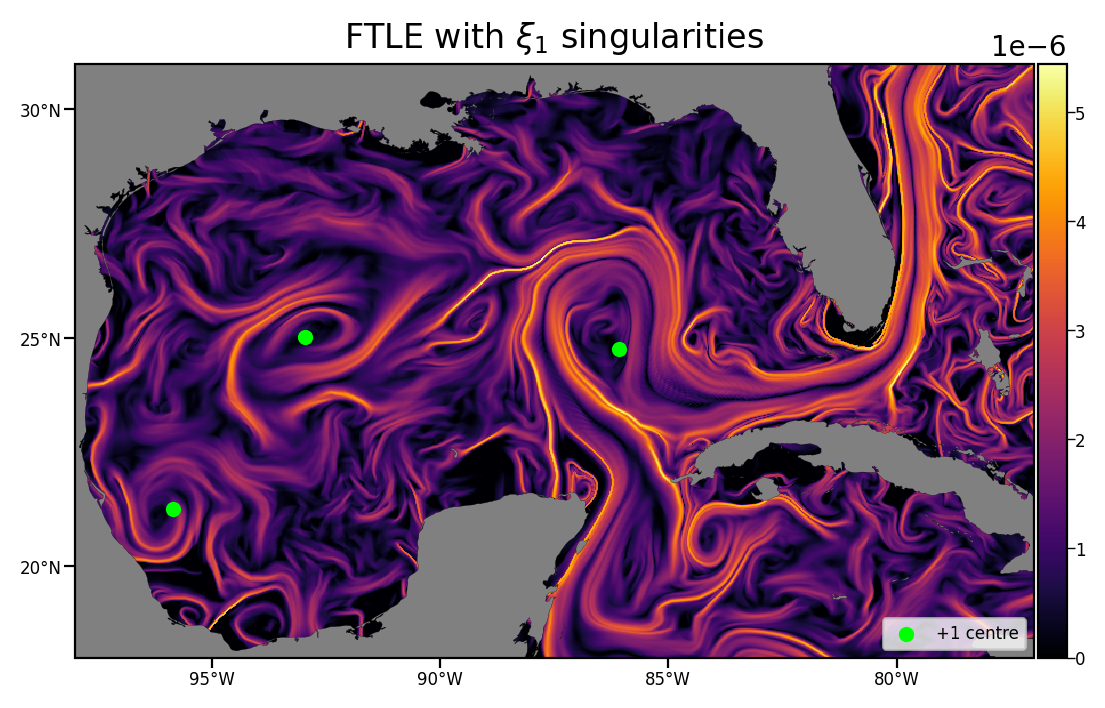

In [8]:
fig = plt.figure(dpi=200)
ax = fig.add_subplot(1, 1, 1, projection=ccrs.PlateCarree())

ftle_plot = np.copy(ftle)
ftle_plot[ftle_plot < 0] = 0
pcm = ax.pcolormesh(ds_traj.xc, ds_traj.yc, ftle_plot, cmap="inferno", transform=ccrs.PlateCarree())
add_colorbar(fig, ax, pcm)

# wedge singularities (+1/2)
wedges = [s for s in sings_merged if abs(s.index - 0.5) < 0.01]
if wedges:
    ax.scatter(
        [s.lon for s in wedges],
        [s.lat for s in wedges],
        s=3,
        c="cyan",
        marker="^",
        transform=ccrs.PlateCarree(),
        label="+½ wedge",
    )

# elliptic centres (+1)
centres = [s for s in sings_merged if abs(s.index - 1.0) < 0.1]
if centres:
    ax.scatter(
        [s.lon for s in centres],
        [s.lat for s in centres],
        s=20,
        c="lime",
        marker="o",
        transform=ccrs.PlateCarree(),
        label="+1 centre",
    )

ax.legend(loc="lower right", fontsize=6)
gom_map(ax)
ax.set_title("FTLE with $\\xi_1$ singularities")

## Elliptic LCS

For each elliptic centre, search for the outermost closed orbit of $\eta^\pm_\lambda$
via a Poincaré section and bisection over $\lambda \in [p_{\min}, p_{\max}]$.

In [9]:
singularities, barriers = lt.elliptic_lcs(
    ds_traj.xc.values,
    ds_traj.yc.values,
    lmin,
    lmax,
    vmin,
    vmax,
    pmin=0.7,
    pmax=2.5,
    n_seeds=100,
    boxradius=5.0,
    combine_radius=combine_radius,
    n_bisection=10,
    max_orbit_length=30.0,
    tolerance=1e-3,
)
print(f"Found {len(barriers)} elliptic barrier(s)")

  find_singularities: 561×919 grid (514,080 cells) …
  raw singularities: 35743 [586×(idx=-0.5), 35157×(idx=+0.5)]
  after merge (r=1.0°): 6 [1×(idx=-0.5), 4×(idx=+1), 1×(idx=+17282)]
  searching 4 centre(s) with 100 seeds × 2 signs over 10 bisection steps …
  bisection: 800 particles (4 centres × ~100 seeds × 2 signs)
  bisection step 0/2 (p_lo) …
100%|██████████| 30.0/30.0 [00:00<00:00, 1433.00it/s]
  bisection step 1/2 (p_hi) …
100%|██████████| 30.0/30.0 [00:00<00:00, 1183.81it/s]
  bisection: 12 / 800 particles have a bracket sign change
  bisection step 2/12: 12 active particles …
100%|██████████| 30.0/30.0 [00:00<00:00, 1617.15it/s]
  bisection step 3/12: 7 active particles …
100%|██████████| 30.0/30.0 [00:00<00:00, 1535.16it/s]
  bisection step 4/12: 7 active particles …
100%|██████████| 30.0/30.0 [00:00<00:00, 1614.39it/s]
  bisection step 5/12: 6 active particles …
100%|██████████| 30.0/30.0 [00:00<00:00, 1510.95it/s]
  bisection step 6/12: 6 active particles …
100%|██████████

/Users/us65093/repos/xlcs/.venv/lib/python3.13/site-packages/parcels/particledata.py:358: UserWarning: 'where' used without 'out', expect unitialized memory in output. If this is intentional, use out=None.
  np.less_equal(time - np.abs(pd["dt"] / 2), pd["time"], where=np.isfinite(pd["time"]))
/Users/us65093/repos/xlcs/.venv/lib/python3.13/site-packages/parcels/particledata.py:359: UserWarning: 'where' used without 'out', expect unitialized memory in output. If this is intentional, use out=None.
  & np.greater_equal(time + np.abs(pd["dt"] / 2), pd["time"], where=np.isfinite(pd["time"]))
/Users/us65093/repos/xlcs/.venv/lib/python3.13/site-packages/parcels/particledata.py:360: UserWarning: 'where' used without 'out', expect unitialized memory in output. If this is intentional, use out=None.
  | ((np.isnan(pd["dt"])) & np.equal(time, pd["time"], where=np.isfinite(pd["time"])))


  integrating final orbit for centre 2 (λ*=1.101660, sign=-1) …
INFO: Output files are stored in /var/folders/jg/mrpxld892dd0yzfc142nmbp00000gp/T/tmpx_aymein/orbit.zarr.


/Users/us65093/repos/xlcs/.venv/lib/python3.13/site-packages/parcels/particledata.py:358: UserWarning: 'where' used without 'out', expect unitialized memory in output. If this is intentional, use out=None.
  np.less_equal(time - np.abs(pd["dt"] / 2), pd["time"], where=np.isfinite(pd["time"]))
/Users/us65093/repos/xlcs/.venv/lib/python3.13/site-packages/parcels/particledata.py:359: UserWarning: 'where' used without 'out', expect unitialized memory in output. If this is intentional, use out=None.
  & np.greater_equal(time + np.abs(pd["dt"] / 2), pd["time"], where=np.isfinite(pd["time"]))
/Users/us65093/repos/xlcs/.venv/lib/python3.13/site-packages/parcels/particledata.py:360: UserWarning: 'where' used without 'out', expect unitialized memory in output. If this is intentional, use out=None.
  | ((np.isnan(pd["dt"])) & np.equal(time, pd["time"], where=np.isfinite(pd["time"])))


  integrating final orbit for centre 3 (λ*=1.043143, sign=-1) …
INFO: Output files are stored in /var/folders/jg/mrpxld892dd0yzfc142nmbp00000gp/T/tmpzs6j3m23/orbit.zarr.


/Users/us65093/repos/xlcs/.venv/lib/python3.13/site-packages/parcels/particledata.py:358: UserWarning: 'where' used without 'out', expect unitialized memory in output. If this is intentional, use out=None.
  np.less_equal(time - np.abs(pd["dt"] / 2), pd["time"], where=np.isfinite(pd["time"]))
/Users/us65093/repos/xlcs/.venv/lib/python3.13/site-packages/parcels/particledata.py:359: UserWarning: 'where' used without 'out', expect unitialized memory in output. If this is intentional, use out=None.
  & np.greater_equal(time + np.abs(pd["dt"] / 2), pd["time"], where=np.isfinite(pd["time"]))
/Users/us65093/repos/xlcs/.venv/lib/python3.13/site-packages/parcels/particledata.py:360: UserWarning: 'where' used without 'out', expect unitialized memory in output. If this is intentional, use out=None.
  | ((np.isnan(pd["dt"])) & np.equal(time, pd["time"], where=np.isfinite(pd["time"])))


  [1/4] centre (-83.38, 17.24) → found
  [2/4] centre (-95.84, 21.24) → none
  [3/4] centre (-86.09, 24.76) → found
  [4/4] centre (-92.96, 25.01) → found
Found 3 elliptic barrier(s)


## Plot elliptic LCS boundaries

Text(0.5, 1.0, 'Elliptic LCS — 3 barriers found')

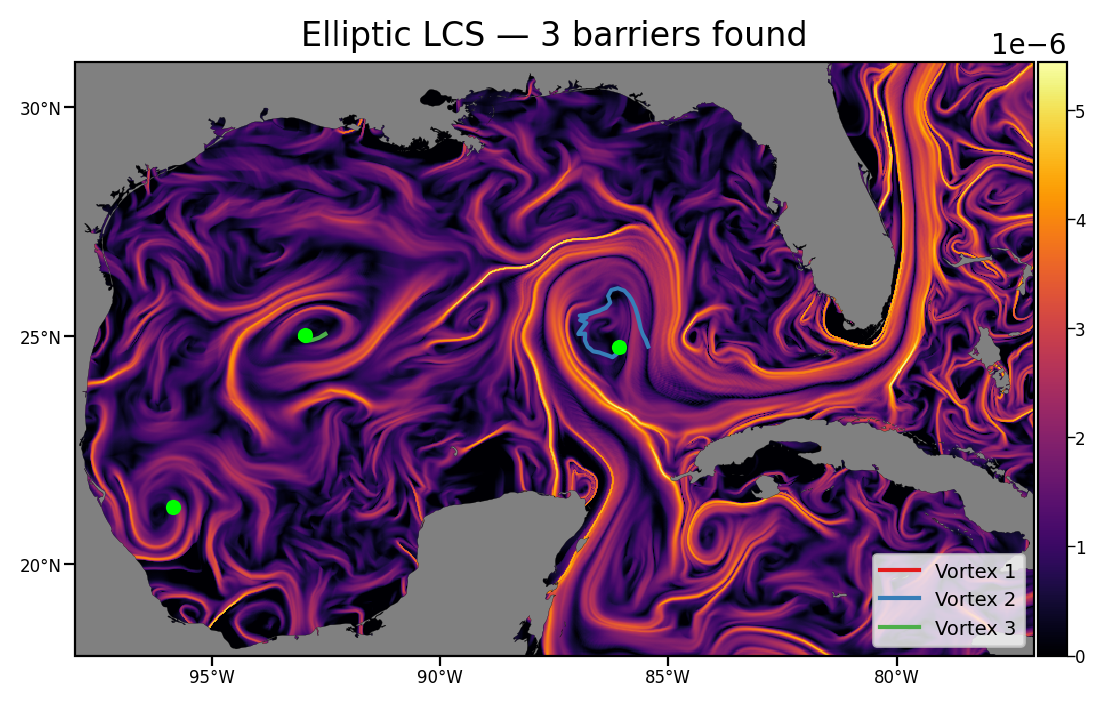

In [10]:
fig = plt.figure(dpi=200)
ax = fig.add_subplot(1, 1, 1, projection=ccrs.PlateCarree())

pcm = ax.pcolormesh(ds_traj.xc, ds_traj.yc, ftle_plot, cmap="inferno", transform=ccrs.PlateCarree())
add_colorbar(fig, ax, pcm)

colors = plt.cm.Set1.colors
for k, barrier in enumerate(barriers):
    # barrier columns: [lat, lon] — same convention as extract_contours
    ax.plot(
        barrier[:, 1],
        barrier[:, 0],
        color=colors[k % len(colors)],
        linewidth=1.5,
        transform=ccrs.PlateCarree(),
        label=f"Vortex {k + 1}",
    )

centres = [s for s in singularities if abs(s.index - 1.0) < 0.1]
if centres:
    ax.scatter(
        [s.lon for s in centres],
        [s.lat for s in centres],
        s=20,
        c="lime",
        marker="o",
        zorder=5,
        transform=ccrs.PlateCarree(),
    )

if barriers:
    ax.legend(loc="lower right", fontsize=7)
gom_map(ax)
ax.set_title(
    f"Elliptic LCS — {len(barriers)} {('barrier' if len(barriers) == 1 else 'barriers')} found"
)